# V2 standardized comparison: 2026-03-26 vs 2026-08-27

This notebook reduces known comparison variables before calculating improvement: identical 200 Hz low-pass bandwidth, 512 Hz sample rate, identical sample count within each upper/lower comparison, timestamp-integrity audit, and process-envelope alignment score. Only raw/unfiltered recordings are used for cross-date improvement. The vendor requirement is strictly |g| < 0.3 g at 265 wafers; available recordings are 250-wafer engineering evidence, not formal acceptance evidence.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str((Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()) / 'scripts'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from audit_data_comparability import standardize, envelope, align, TARGET_FS, COMMON_CUTOFF_HZ
from generate_vibration_report import load_recdata, calculate_metrics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False


In [2]:
DATASETS = {
    '2026-03-26 upper/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260326\上手\RecData--20260326133043上手.csv'),
    '2026-08-27 upper J5/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\上手J5\RecData--20260827115016.csv'),
    '2026-03-26 lower/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260326\下手\RecData--20260326133043下手.csv'),
    '2026-08-27 lower J4/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\下手J4\RecData--20260827115019.csv'),
}
GROUPS = {
    'Upper gripper': ['2026-03-26 upper/raw', '2026-08-27 upper J5/raw'],
    'Lower gripper': ['2026-03-26 lower/raw', '2026-08-27 lower J4/raw'],
}
THRESHOLD_G = 0.3
DISPLAY_MAX_POINTS = 60_000


In [3]:
raw, metadata, audit_rows = {}, {}, []
for label, path in DATASETS.items():
    frame, meta = load_recdata(path)
    raw[label], metadata[label] = frame, meta
    dt = frame.time_s.diff().dropna().median()
    expected = round((frame.time_s.iloc[-1] - frame.time_s.iloc[0]) / dt) + 1
    audit_rows.append({
        'dataset': label, 'start': meta.get('Date/Time', 'missing'),
        'inferred_Hz': 1 / dt, 'samples': len(frame),
        'duration_s': frame.time_s.iloc[-1] - frame.time_s.iloc[0],
        'timeline_missing_samples': max(0, expected - len(frame)),
        'duplicate_timestamps': frame.time_s.duplicated().sum(),
        'large_time_gaps': (frame.time_s.diff() > 1.5 * dt).sum(),
    })
audit = pd.DataFrame(audit_rows).set_index('dataset')
display(audit.round(6))

standardized = {label: standardize(frame) for label, frame in raw.items()}
windows, window_rows = {}, []
for group, labels in GROUPS.items():
    common_samples = min(len(standardized[label]) for label in labels)
    for label in labels:
        windows[label] = standardized[label].iloc[:common_samples].copy()
    window_rows.append({'group': group, 'common_samples': common_samples, 'common_duration_s': (common_samples - 1) / TARGET_FS})
print(f'Common processing: 4th-order zero-phase low-pass {COMMON_CUTOFF_HZ:.0f} Hz; sample rate {TARGET_FS:.0f} Hz')
display(pd.DataFrame(window_rows).set_index('group'))


,start,inferred_Hz,samples,duration_s,timeline_missing_samples,duplicate_timestamps,large_time_gaps
dataset,,,,,,,
2026-03-26 upper/raw,2026/03/26 13:30:43,1024.000524,402432,392.999023,0,0,0
2026-08-27 upper J5/raw,2026/08/27 11:50:16,1024.000524,359936,351.499023,0,0,0
2026-03-26 lower/raw,2026/03/26 13:30:43,512.000000,201216,392.998047,0,0,0
2026-08-27 lower J4/raw,2026/08/27 11:50:19,1024.000524,363520,354.999023,0,0,0


Common processing: 4th-order zero-phase low-pass 200 Hz; sample rate 512 Hz


,common_samples,common_duration_s
group,,
Upper gripper,179968,351.498047
Lower gripper,181760,354.998047


In [4]:
alignment_rows = []
for group, labels in GROUPS.items():
    benchmark, august = labels[0], labels[-1]
    lag_s, correlation, overlap_s = align(envelope(standardized[august]), envelope(standardized[benchmark]))
    alignment_rows.append({
        'group': group, 'estimated_lag_s': lag_s, 'envelope_correlation': correlation,
        'overlap_s': overlap_s, 'phase_alignment_gate': 'PASS' if correlation >= 0.5 else 'FAIL',
    })
alignment_audit = pd.DataFrame(alignment_rows).set_index('group')
display(alignment_audit.round(4))
print('FAIL means improvement remains conditional: timestamps alone cannot identify the same robot-motion/wafer-holding phase.')


,estimated_lag_s,envelope_correlation,overlap_s,phase_alignment_gate
group,,,,
Upper gripper,-21.5,0.0753,330.0,FAIL
Lower gripper,-97.5,0.0786,257.5,FAIL


FAIL means improvement remains conditional: timestamps alone cannot identify the same robot-motion/wafer-holding phase.


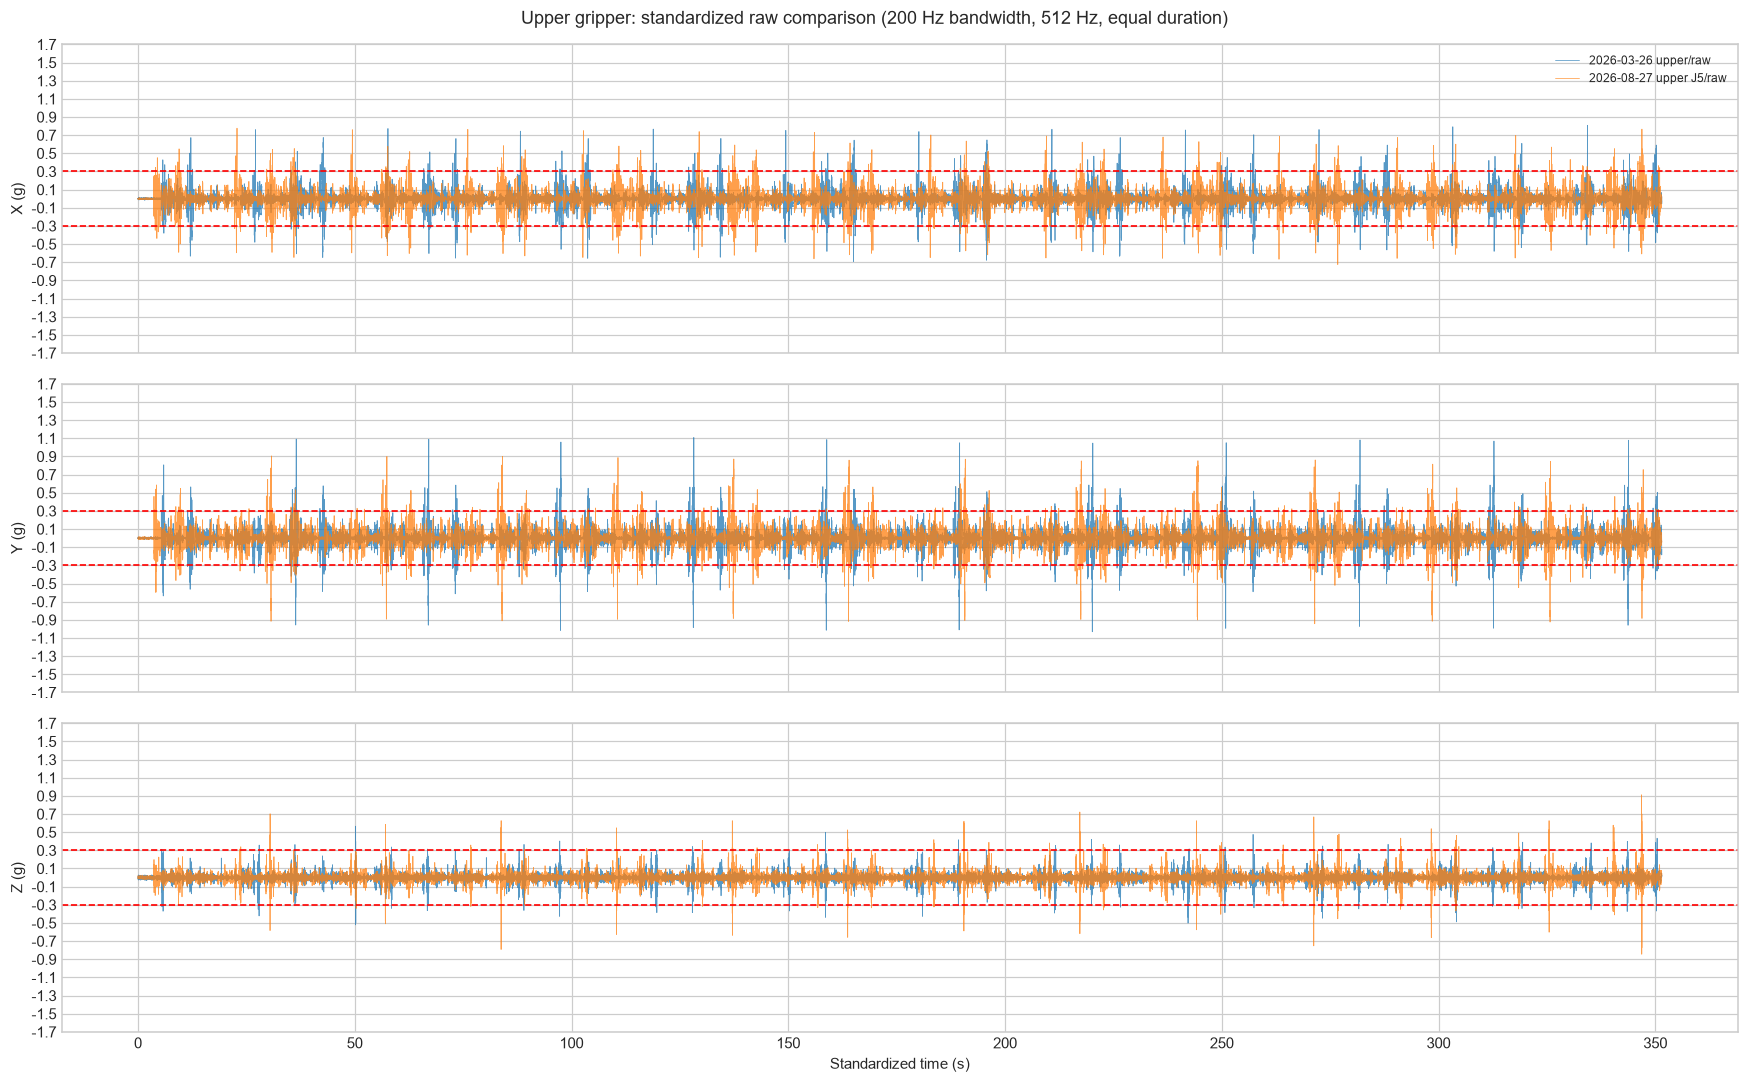

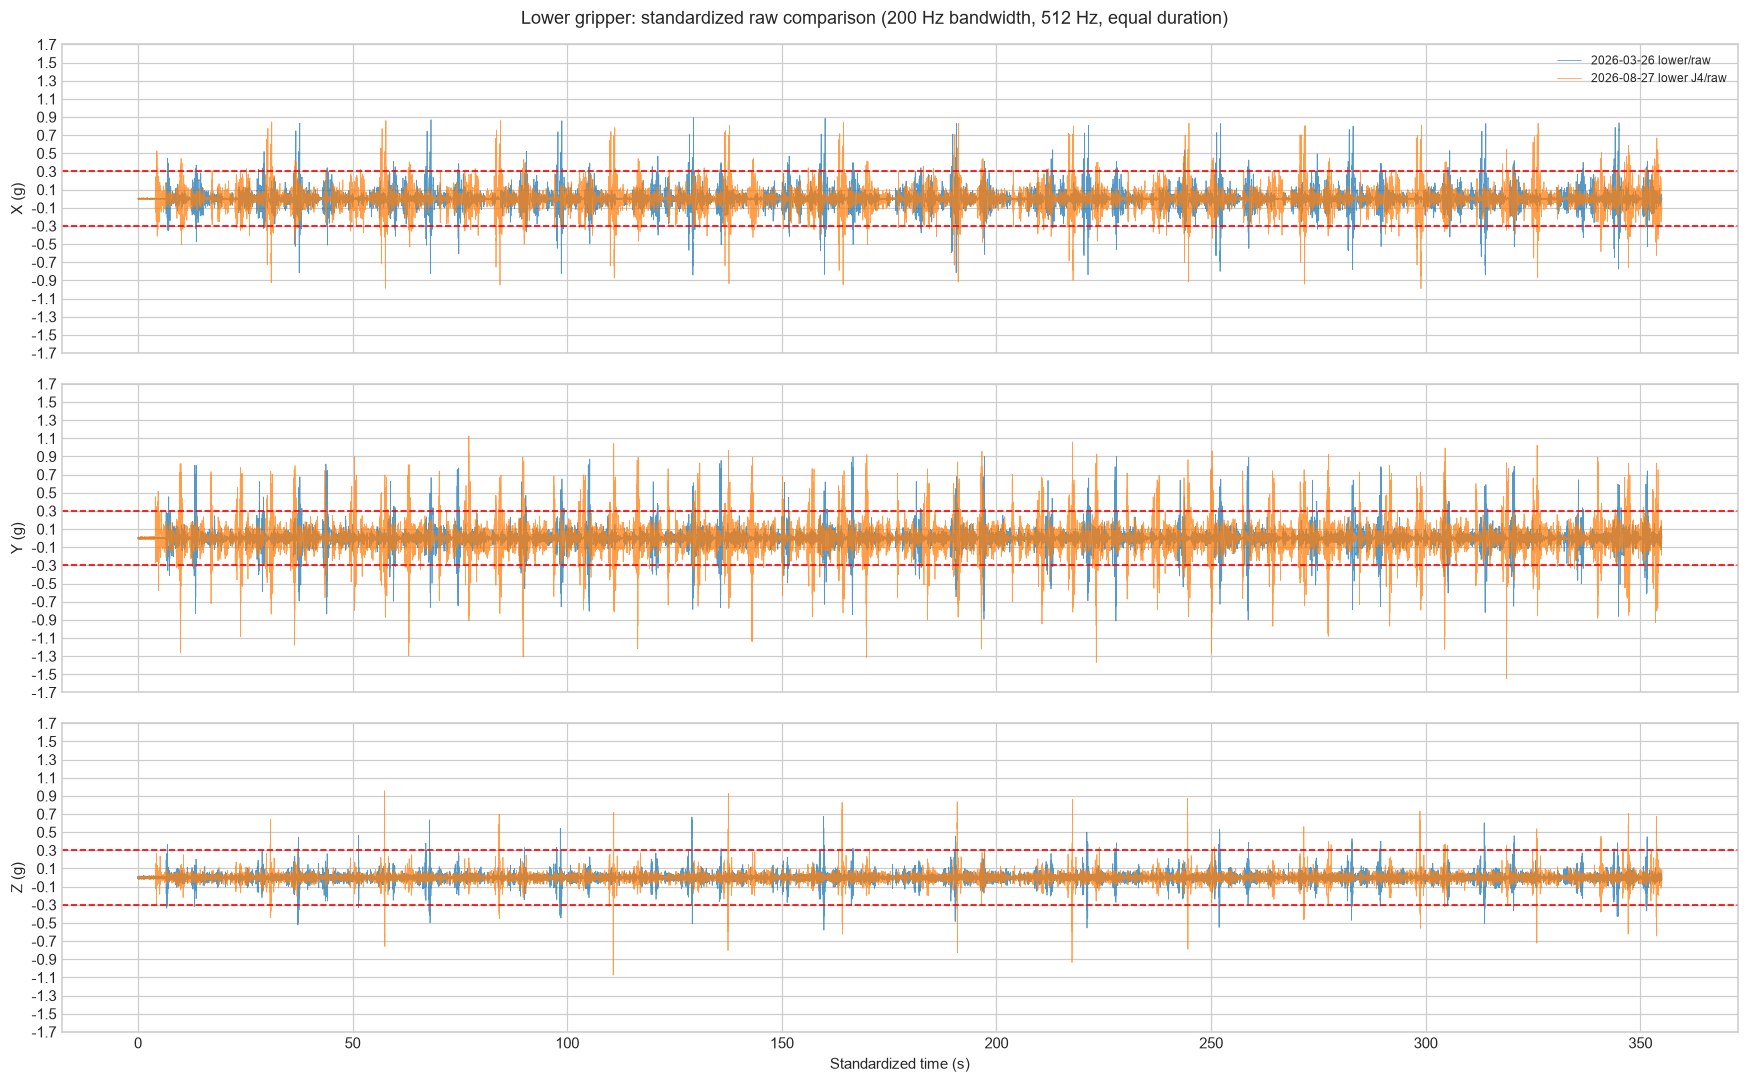

In [5]:
global_abs = max(frame[['X','Y','Z']].abs().to_numpy().max() for frame in windows.values())
y_limit = np.ceil(global_abs * 1.03 / 0.1) * 0.1
y_ticks = np.arange(-y_limit, y_limit + 0.1, 0.2)
for group, labels in GROUPS.items():
    fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True, sharey=True)
    for axis, ax in zip('XYZ', axs):
        for label in labels:
            frame = windows[label]
            step = max(1, int(np.ceil(len(frame) / DISPLAY_MAX_POINTS)))
            ax.plot(frame.time_s.iloc[::step], frame[axis].iloc[::step], lw=0.5, alpha=0.75, label=label)
        ax.axhline(THRESHOLD_G, color='red', ls='--', lw=1.1)
        ax.axhline(-THRESHOLD_G, color='red', ls='--', lw=1.1)
        ax.set_ylim(-y_limit, y_limit); ax.set_yticks(y_ticks); ax.set_ylabel(f'{axis} (g)')
    axs[0].legend(fontsize=8); axs[-1].set_xlabel('Standardized time (s)')
    fig.suptitle(f'{group}: standardized raw comparison (200 Hz bandwidth, 512 Hz, equal duration)')
    fig.tight_layout(); plt.show()


RMS_g  P99_abs_g  P99.9_abs_g  Max_abs_g  \
dataset                 axis                                               
2026-03-26 upper/raw    X     0.08799    0.38082      0.61604    0.80882   
                        Y     0.09104    0.37494      0.74399    1.12421   
                        Z     0.04295    0.18788      0.33781    0.59499   
2026-08-27 upper J5/raw X     0.09923    0.39240      0.63478    0.79525   
                        Y     0.10545    0.40293      0.82862    0.94316   
                        Z     0.05277    0.21813      0.45306    1.15079   
2026-03-26 lower/raw    X     0.09409    0.36183      0.75521    0.89227   
                        Y     0.09285    0.40556      0.73498    0.93234   
                        Z     0.04641    0.19158      0.41384    0.68741   
2026-08-27 lower J4/raw X     0.10803    0.41349      0.79622    0.99093   
                        Y     0.13590    0.56772      0.96304    1.58504   
                        Z     0.05507    0.20343      0.66864    1.07405   

                              Within_pct  Exceed_pct  Events_per_min  \
dataset                 axis                                           
2026-03-26 upper/raw    X       98.20690     1.79310        70.49787   
                        Y       98.35137     1.64863        92.34708   
                        Z       99.81274     0.18726        53.42817   
2026-08-27 upper J5/raw X       97.64736     2.35264       138.94737   
                        Y       97.76794     2.23206        99.34566   
                        Z       99.62660     0.37340        82.95875   
2026-03-26 lower/raw    X       98.42099     1.57901        76.05634   
                        Y       97.95830     2.04170       112.73239   
                        Z       99.66494     0.33506        87.21127   
2026-08-27 lower J4/raw X       97.55887     2.44113       113.91549   
                        Y       95.50121     4.49879       305.07042   
                        Z       99.50924     0.49076        73.35211   

                              Max_event_ms  
dataset                 axis                
2026-03-26 upper/raw    X        107.42188  
                        Y         89.84375  
                        Z         11.71875  
2026-08-27 upper J5/raw X         74.21875  
                        Y        103.51562  
                        Z         29.29688  
2026-03-26 lower/raw    X         95.70312  
                        Y         41.01562  
                        Z          9.76562  
2026-08-27 lower J4/raw X        109.37500  
                        Y         44.92188  
                        Z         41.01562


RMS_g


RMS_g_benchmark  RMS_g_august  RMS_g_improvement_pct
group         axis                                                      
Upper gripper X              0.0880        0.0992               -12.7723
              Y              0.0910        0.1054               -15.8243
              Z              0.0430        0.0528               -22.8500
Lower gripper X              0.0941        0.1080               -14.8131
              Y              0.0929        0.1359               -46.3549
              Z              0.0464        0.0551               -18.6487


P99_abs_g


P99_abs_g_benchmark  P99_abs_g_august  \
group         axis                                          
Upper gripper X                  0.3808            0.3924   
              Y                  0.3749            0.4029   
              Z                  0.1879            0.2181   
Lower gripper X                  0.3618            0.4135   
              Y                  0.4056            0.5677   
              Z                  0.1916            0.2034   

                    P99_abs_g_improvement_pct  
group         axis                             
Upper gripper X                       -3.0407  
              Y                       -7.4654  
              Z                      -16.1041  
Lower gripper X                      -14.2754  
              Y                      -39.9814  
              Z                       -6.1866

...

Exceed_pct_benchmark  Exceed_pct_august  \
group         axis                                            
Upper gripper X                   1.7931             2.3526   
              Y                   1.6486             2.2321   
              Z                   0.1873             0.3734   
Lower gripper X                   1.5790             2.4411   
              Y                   2.0417             4.4988   
              Z                   0.3351             0.4908   

                    Exceed_pct_improvement_pct  
group         axis                              
Upper gripper X                       -31.2055  
              Y                       -35.3893  
              Z                       -99.4065  
Lower gripper X                       -54.5993  
              Y                      -120.3449  
              Z                       -46.4696


Events_per_min


Events_per_min_benchmark  Events_per_min_august  \
group         axis                                                    
Upper gripper X                      70.4979               138.9474   
              Y                      92.3471                99.3457   
              Z                      53.4282                82.9587   
Lower gripper X                      76.0563               113.9155   
              Y                     112.7324               305.0704   
              Z                      87.2113                73.3521   

                    Events_per_min_improvement_pct  
group         axis                                  
Upper gripper X                           -97.0944  
              Y                            -7.5786  
              Z                           -55.2716  
Lower gripper X                           -49.7778  
              Y                          -170.6147  
              Z                            15.8915


Max_event_ms


Max_event_ms_benchmark  Max_event_ms_august  \
group         axis                                                
Upper gripper X                   107.4219              74.2188   
              Y                    89.8438             103.5156   
              Z                    11.7188              29.2969   
Lower gripper X                    95.7031             109.3750   
              Y                    41.0156              44.9219   
              Z                     9.7656              41.0156   

                    Max_event_ms_improvement_pct  
group         axis                                
Upper gripper X                          30.9091  
              Y                         -15.2174  
              Z                        -150.0000  
Lower gripper X                         -14.2857  
              Y                          -9.5238  
              Z                        -320.0000

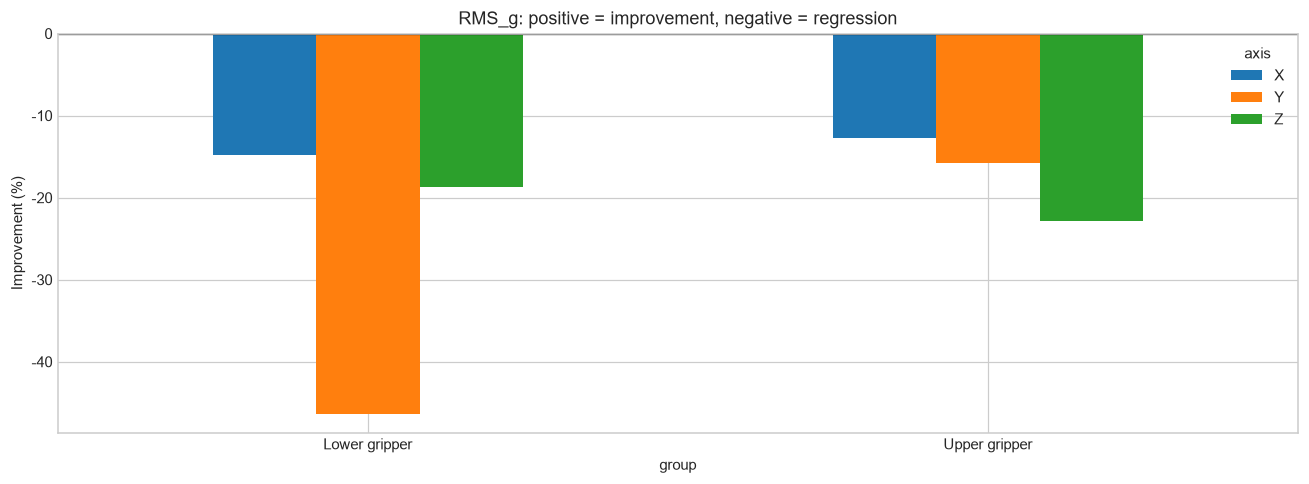

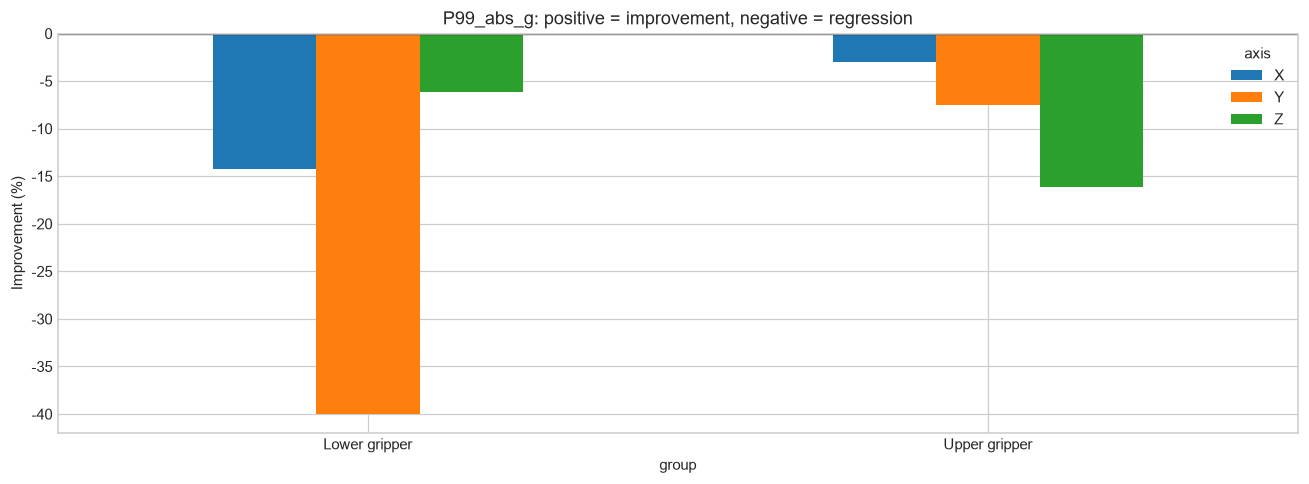

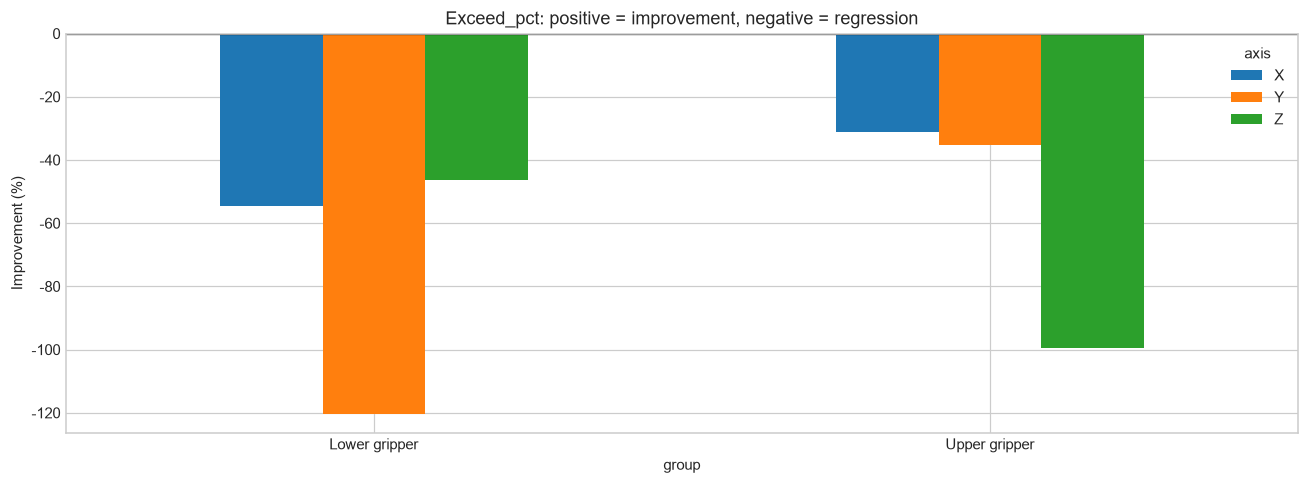

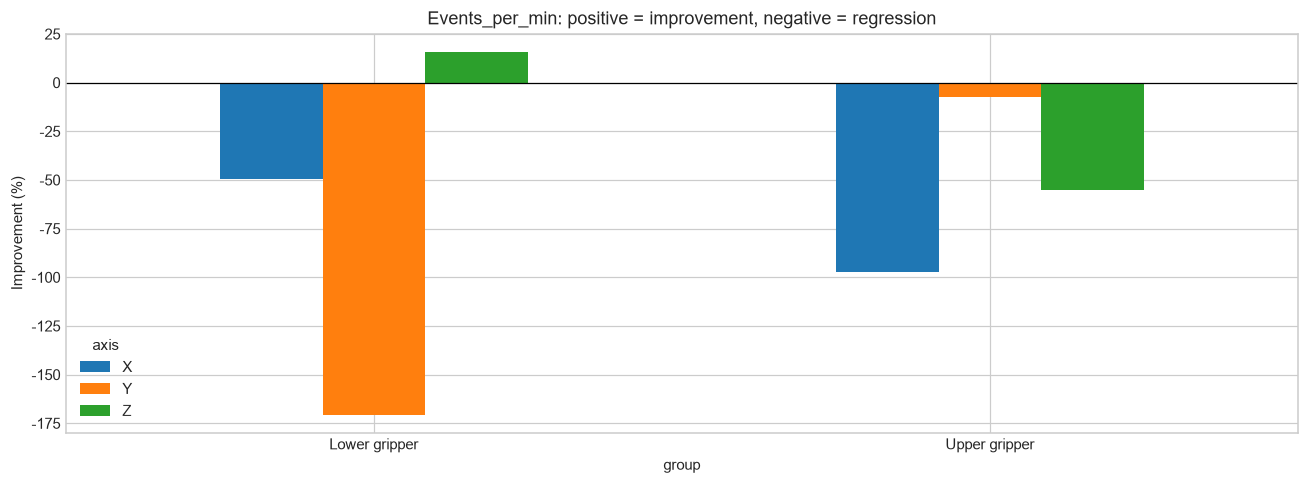

In [6]:
metrics = calculate_metrics(windows)
display(metrics[['RMS_g','P99_abs_g','P99.9_abs_g','Max_abs_g','Within_pct','Exceed_pct','Events_per_min','Max_event_ms']].round(5))

LOWER_BETTER = ['RMS_g','P99_abs_g','P99.9_abs_g','Max_abs_g','Exceed_pct','Events_per_min','Max_event_ms']
rows = []
for group, labels in GROUPS.items():
    baseline_labels, august_label = labels[:-1], labels[-1]
    baseline = pd.concat([metrics.loc[label] for label in baseline_labels]).groupby(level=0).mean()
    august = metrics.loc[august_label]
    for axis in 'XYZ':
        row = {'group': group, 'axis': axis}
        for metric in LOWER_BETTER:
            old, new = baseline.loc[axis, metric], august.loc[axis, metric]
            row[f'{metric}_benchmark'] = old; row[f'{metric}_august'] = new
            row[f'{metric}_improvement_pct'] = 100 * (old - new) / old if old else np.nan
        rows.append(row)
improvement = pd.DataFrame(rows).set_index(['group','axis'])
for metric in LOWER_BETTER:
    print(f'\n{metric}')
    display(improvement[[f'{metric}_benchmark',f'{metric}_august',f'{metric}_improvement_pct']].round(4))

for metric in ['RMS_g','P99_abs_g','Exceed_pct','Events_per_min']:
    chart = improvement[f'{metric}_improvement_pct'].unstack('axis')
    ax = chart.plot.bar(figsize=(12,4.5)); ax.axhline(0,color='black',lw=.8)
    ax.set_ylabel('Improvement (%)'); ax.set_title(f'{metric}: positive = improvement, negative = regression')
    ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()


## Interpretation boundary

The standardized metrics remove sampling-rate, bandwidth, and record-length differences. They do not prove that the same motion phase or wafer-holding interval was captured. When the phase-alignment gate fails, improvement percentages are conditional engineering indicators only. Formal validation requires synchronized GPST/motion-step timestamps and a repeated 265-wafer test.